In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from typing import List
from transformers import PreTrainedTokenizerFast

plt.rcParams["font.family"] = "Courier New"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

c:\Users\Haeohreum Kim\miniconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


we now aim to train a language model, including the embedding model using LSTM. we start with a single layer (ensuring our setup is modular), consider any training considerations, and then create a deeper network which will be left to train for a longer time (although, this will not be done on this notebook).

In [2]:
class LSTMLangModel(nn.Module):
    def __init__(self, hidden_size: List[int], num_layers: int, vocab_size: int, embedding_size: int):
        """
        input size should be vocabulary size
        """
        super().__init__()

        # embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_size)

        # hidden layers
        tmp_size = embedding_size
        self.layers: nn.ModuleList = nn.ModuleList()
        for layer in range(num_layers):
            self.layers.append(nn.LSTM(tmp_size, hidden_size[layer], 1, batch_first=True))
            tmp_size = hidden_size[layer]

        # linear output
        self.output = nn.Linear(tmp_size, vocab_size)

    
    def forward(self, token_ids):
        x = self.embedding(token_ids)

        for layer in self.layers: x, _ = layer(x)

        logits = self.output(x)

        return logits

we need to do some cleaning of our data set. samples should be split up into a fixed amount of tokens, such that the LSTM can do training cross-sectionally at each recurrence `t`.
1. pull in short stories data set, and tokenize the stories into sequences
2. add the `<|endoftext|>` token at the end of each of the stories (token id 50256)
3. split up the data into a panel of `n` token sequences; remove the remaining tokens that do not fill a total `n` token sequence

In [9]:
DATA_PATH = 'C:/data/tinystories/data'
OUTPUT_DIR = r"C:/data/tinystories/processed"

# tokeniser; a tokeniser trained specifically for the tiny stories dataset
tokeniser = PreTrainedTokenizerFast.from_pretrained('vuiseng9/bpe-10.0k-tinystories')

# pull in data
datasets = os.listdir(DATA_PATH)
tr_datasets, tst_datasets = [f'{DATA_PATH}/{d}' for d in datasets if 'train' in d], [f'{DATA_PATH}/{d}' for d in datasets if 'validation' in d]

In [4]:
tr_dump = []

for tr_path in tr_datasets:
    tr_data = pd.read_parquet(tr_path)
    tr_dump.append(tr_data)

tst_data_total = pd.read_parquet(tst_datasets[0])
tr_data_total = pd.concat(tr_dump).reset_index(drop=True)

batch encode the text, and then create a panel of `(n_samples, sequence_length)`. we will then embed these, which will turn the data into shape `(n_samples, sequence_length, embedding dimension)`.

In [5]:
def write_token_file(dataframe, output_path, tokeniser, batch_size=256,):
    total_tokens = 0
    total_documents = 0

    with open(output_path, "wb") as f:

        for start in range(0, len(dataframe), batch_size):
            texts = dataframe["text"].iloc[start:start + batch_size].tolist()
            encoded = tokeniser(texts, add_special_tokens=False, padding=False, truncation=False,)

            for token_ids in encoded["input_ids"]:
                # add eos token
                token_ids.append(tokeniser.eos_token_id)

                # save down as numpy array, these can be streamed later on
                arr = np.asarray(token_ids, dtype=np.uint16,)
                arr.tofile(f)

                total_tokens += len(arr)
                total_documents += 1

            if start % (batch_size * 100) == 0:
                progress = f"{start:,}/{len(dataframe):,} documents"
                print(f"{progress:<35} :: "f"{total_tokens:,} tokens")

            del texts
            del encoded

    print(f"Saved {total_documents:,} documents / " f"{total_tokens:,} tokens -> {output_path}")

save down the tokenised data sets for other research projects.

In [7]:
write_token_file(tr_data_total, os.path.join(OUTPUT_DIR, "train.bin"), tokeniser,)
write_token_file(tst_data_total, os.path.join(OUTPUT_DIR, "test.bin"), tokeniser,)

0/2,119,719 documents               :: 49,498 tokens
25,600/2,119,719 documents          :: 5,644,574 tokens
51,200/2,119,719 documents          :: 11,163,477 tokens
76,800/2,119,719 documents          :: 16,739,028 tokens
102,400/2,119,719 documents         :: 22,056,321 tokens
128,000/2,119,719 documents         :: 27,865,649 tokens
153,600/2,119,719 documents         :: 33,584,393 tokens
179,200/2,119,719 documents         :: 39,545,955 tokens
204,800/2,119,719 documents         :: 45,299,379 tokens
230,400/2,119,719 documents         :: 50,963,648 tokens
256,000/2,119,719 documents         :: 56,732,991 tokens
281,600/2,119,719 documents         :: 62,368,941 tokens
307,200/2,119,719 documents         :: 68,048,815 tokens
332,800/2,119,719 documents         :: 73,507,513 tokens
358,400/2,119,719 documents         :: 79,220,751 tokens
384,000/2,119,719 documents         :: 84,626,589 tokens
409,600/2,119,719 documents         :: 90,329,730 tokens
435,200/2,119,719 documents         

now, implement a `DataSet` such that the fixed sequence length is parameterisable, and the `DataSet` returns the correct shape of `n`-length sequences.

In [5]:
class LMDataset(Dataset):
    def __init__(self, path: str, seq_len: int):
        self.tokens = np.memmap(path, dtype=np.uint16, mode='r')
        self.seq_len = seq_len

    def __len__(self):
        # returns a whole number of the amount of sequences with seq_len length.
        # doesn't include a possible remainder sequence
        return (len(self.tokens) - 1) // self.seq_len

    def __getitem__(self, idx):
        start = idx * self.seq_len
        chunk = self.tokens[start:start+self.seq_len+1].astype(np.int64)
        # below is essentially shifted; so token[i] vs token[i+1]
        x = torch.from_numpy(chunk[:-1])
        y = torch.from_numpy(chunk[1:])

        return x, y

we can now finally test whether our model works as intended, with our 128 length sequences. we train for just one epoch across our training data, and then consider the validation loss as well as a simulated query v.s. response.

In [6]:
tr_data = LMDataset(r'C:/data/tinystories/processed/train.bin', seq_len=128)
tst_data = LMDataset(r'C:/data/tinystories/processed/test.bin', seq_len=128)

# data loader, pin memory into cpu for fast transfer to gpu
tr_loader = DataLoader(tr_data, batch_size=48, shuffle=True, pin_memory=True, num_workers=0)
tst_loader = DataLoader(tst_data, batch_size=48, shuffle=False)

In [ ]:
# model stuff. i choose 768 neurons because this is what gpt-1 used.
lm = LSTMLangModel([768], 1, tokeniser.vocab_size, 256).to(device)
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(lm.parameters(), lr=1e-3, fused=True)

# training loop

loss_hist = []

lm.train()
total_loss = 0.0
tokens = 0
total_batches = len(tr_loader)

for batch_idx, (X_batch, y_batch) in enumerate(tr_loader, start=1):
    X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
    y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

    optimiser.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = lm(X_batch)
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

    loss.backward()
    optimiser.step()

    n_tokens = y_batch.numel()

    total_loss += loss.detach().item() * n_tokens
    tokens += n_tokens

    avg_loss = total_loss / tokens

    loss_hist.append({ 'i': batch_idx, 'avg_loss': avg_loss })

    if batch_idx % 1000 == 0 or batch_idx == total_batches:
        progress = 100 * batch_idx / total_batches

        print(
            f"batch {batch_idx}/{total_batches} ({progress:.1f}%) :: "
            f"avg loss: {avg_loss:.4f}",
            flush=True,
        )

batch 1000/75679 (1.3%) :: avg loss: 4.3044
batch 2000/75679 (2.6%) :: avg loss: 4.0035
batch 3000/75679 (4.0%) :: avg loss: 3.8543
batch 4000/75679 (5.3%) :: avg loss: 3.7570
batch 5000/75679 (6.6%) :: avg loss: 3.6859
batch 6000/75679 (7.9%) :: avg loss: 3.6315
batch 7000/75679 (9.2%) :: avg loss: 3.5884
batch 8000/75679 (10.6%) :: avg loss: 3.5525
batch 9000/75679 (11.9%) :: avg loss: 3.5222
batch 10000/75679 (13.2%) :: avg loss: 3.4965
batch 11000/75679 (14.5%) :: avg loss: 3.4741
batch 12000/75679 (15.9%) :: avg loss: 3.4548
batch 13000/75679 (17.2%) :: avg loss: 3.4367
batch 14000/75679 (18.5%) :: avg loss: 3.4212
batch 15000/75679 (19.8%) :: avg loss: 3.4070
batch 16000/75679 (21.1%) :: avg loss: 3.3943
batch 17000/75679 (22.5%) :: avg loss: 3.3826
batch 18000/75679 (23.8%) :: avg loss: 3.3719
batch 19000/75679 (25.1%) :: avg loss: 3.3622
batch 20000/75679 (26.4%) :: avg loss: 3.3532
batch 21000/75679 (27.7%) :: avg loss: 3.3449
batch 22000/75679 (29.1%) :: avg loss: 3.3380
batc

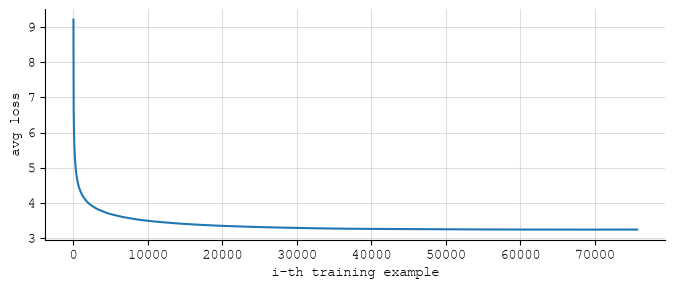

In [21]:
loss_hist_df = pd.DataFrame(loss_hist)
plt.figure(figsize=(8, 3))
plt.plot(loss_hist_df['i'], loss_hist_df['avg_loss'])
plt.grid(alpha=0.4)
plt.xlabel('i-th training example')
plt.ylabel('avg loss')
sns.despine()

how does the model perform on the validation set? perplexity can be roughly considered the number of tokens/words that a model picks from at a given prediction. perplexity is given by
$$ PPL = \exp^{\tilde{L}}$$

where $\tilde{L}$ is the average loss on the validation est. thus as $\tilde{L} \to 0$, $PPL \to 1$; or more simply, the model always accurately predicts the next word, as it only considers one word. consider a sequence of tokens $x_1, x_2, \dots, x_N$. the problem of language models could be defined as a joint probability

$$ P(x_1, x_2, \dots, x_N) = \prod_{t=1}^N P(x_t | x_1, \dots, x_{t-1})$$
as $N \to \infty$, each individual probability $\to 0$, and thus the geometric mean is used. the geometric mean gives the average probability of predicting the word across the entire sequence, and the reciprocal gives the average number of words "considered".

$$ PPL = \left(\prod_{t=1}^N P(x_t | x_{<t}) \right)^{-1/N}$$

In [ ]:
total_valid_loss = 0
valid_tokens = 0

with torch.no_grad():
    lm.eval()

    for X_batch, y_batch in tst_loader:
        X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
        y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

        logits = lm(X_batch)
        # logits is of shape [batch_size, seq_len, vocab_size]
        # but loss is generally calculated on [number_of_predictions, number_of_classes]
        # thus logits.reshape(-1, tokeniser.vocab_size) combines the first two dimensions batch_size * seq_len
        # that is, it flattens the 3d matrix to a 2d matrix. same for y_batch but that is a 2d matrix
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

        n_tokens = y_batch.numel()
        total_valid_loss += loss.detach().item() * n_tokens
        valid_tokens += n_tokens

avg_valid_loss = total_valid_loss / valid_tokens
perplexity = np.exp(avg_valid_loss)

print(f'avg valid loss :: {round(avg_valid_loss, 4)}')
print(f'perplexity :: {round(perplexity, 4)}')

avg valid loss :: 3.3403
perplexity :: 28.2268


In [87]:
example_query = 'Once upon a time, there was a man called Jeff. He was very good at maths.'
tokens = torch.tensor(tokeniser.encode(example_query), dtype=torch.long, device=device).unsqueeze(0)

lm.eval()

response = example_query

with torch.no_grad():
    while True:
        logits = lm(tokens)
        next_token_logits = logits[0, -1, :]

        # 
        probs = torch.softmax(next_token_logits, dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()

        if next_token_id == tokeniser.eos_token_id: break

        response = response + tokeniser.decode(next_token_id)

        # append new token
        next_token = torch.tensor([[next_token_id]], dtype=torch.long, device=device)
        tokens = torch.cat([tokens, next_token], dim=1)

print(textwrap.fill(response, width=80))

Once upon a time, there was a man called Jeff. He was very good at maths.  One
day, Lily and Ben came to join them. They watched as the squirrel so a big fit
heart had passed the dancing better too. It was definitely pretty and still
finally wide flames. She did not know how to sing up and down and was going so
all around the rabbit looked slow for miles. But Bucky was growing and too. He
started to run and laughed and wouldn't reach the wrap. He was so happy that she
had done wrong! She gave them how the chance he behaved anymore.   Katie
remembered how helpful she did her, she felt really happy.  When Sally was still
still playing with their things, she heard a pretty little bird that she said to
the animal, "I love you for making her bark. My friend will wash it. You did
something even when you don't now".  Tim carefully climb up and saw yellow for
its wet snakes and were sad. Then she heard a loud voice. She said, "I hope it
makes you loud with a surprise. The storm is too strong! 

the one-layer LSTM model generally learns to tell a story with some form, but it's clear that it is not capturing context appropiately, particularly with the gender of nouns, etc. i noticed during tuning that a *wider* network generally seemed to yield better results, so let us try to double the width of our hidden layer.

In [7]:
lm_v2 = LSTMLangModel([768 * 2], 1, tokeniser.vocab_size, 256).to(device)
loss_fn = nn.CrossEntropyLoss()
optimiser_v2 = torch.optim.Adam(lm_v2.parameters(), lr=1e-3, fused=True)

# training loop

loss_hist_v2 = []

lm_v2.train()
total_loss = 0.0
tokens = 0
total_batches = len(tr_loader)

for batch_idx, (X_batch, y_batch) in enumerate(tr_loader, start=1):
    X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
    y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

    optimiser_v2.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = lm_v2(X_batch)
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

    loss.backward()
    optimiser_v2.step()

    n_tokens = y_batch.numel()

    total_loss += loss.detach().item() * n_tokens
    tokens += n_tokens

    avg_loss = total_loss / tokens

    loss_hist_v2.append({ 'i': batch_idx, 'avg_loss': avg_loss })

    if batch_idx % 1000 == 0 or batch_idx == total_batches:
        progress = 100 * batch_idx / total_batches

        print(
            f"batch {batch_idx}/{total_batches} ({progress:.1f}%) :: "
            f"avg loss: {avg_loss:.4f}",
            flush=True,
        )

batch 1000/75679 (1.3%) :: avg loss: 4.2306
batch 2000/75679 (2.6%) :: avg loss: 3.9414
batch 3000/75679 (4.0%) :: avg loss: 3.7956
batch 4000/75679 (5.3%) :: avg loss: 3.7024
batch 5000/75679 (6.6%) :: avg loss: 3.6376
batch 6000/75679 (7.9%) :: avg loss: 3.5872
batch 7000/75679 (9.2%) :: avg loss: 3.5467
batch 8000/75679 (10.6%) :: avg loss: 3.5141
batch 9000/75679 (11.9%) :: avg loss: 3.4865
batch 10000/75679 (13.2%) :: avg loss: 3.4639
batch 11000/75679 (14.5%) :: avg loss: 3.4436
batch 12000/75679 (15.9%) :: avg loss: 3.4259
batch 13000/75679 (17.2%) :: avg loss: 3.4111
batch 14000/75679 (18.5%) :: avg loss: 3.3976
batch 15000/75679 (19.8%) :: avg loss: 3.3854
batch 16000/75679 (21.1%) :: avg loss: 3.3745
batch 17000/75679 (22.5%) :: avg loss: 3.3641
batch 18000/75679 (23.8%) :: avg loss: 3.3555
batch 19000/75679 (25.1%) :: avg loss: 3.3476
batch 20000/75679 (26.4%) :: avg loss: 3.3399
batch 21000/75679 (27.7%) :: avg loss: 3.3330
batch 22000/75679 (29.1%) :: avg loss: 3.3263
batc

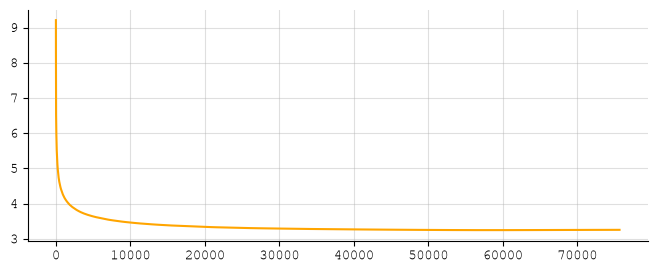

In [16]:
loss_hist_df_v2 = pd.DataFrame(loss_hist_v2)

plt.figure(figsize=(8, 3))
plt.plot(loss_hist_df_v2['i'], loss_hist_df_v2['avg_loss'], color='orange')
plt.grid(alpha=0.4)
sns.despine()

consider the performance on the validation set.

In [9]:
total_valid_loss_v2 = 0
valid_tokens_v2 = 0

with torch.no_grad():
    lm_v2.eval()

    for X_batch, y_batch in tst_loader:
        X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
        y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

        logits = lm_v2(X_batch)
        # logits is of shape [batch_size, seq_len, vocab_size]
        # but loss is generally calculated on [number_of_predictions, number_of_classes]
        # thus logits.reshape(-1, tokeniser.vocab_size) combines the first two dimensions batch_size * seq_len
        # that is, it flattens the 3d matrix to a 2d matrix. same for y_batch but that is a 2d matrix
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

        total_valid_loss_v2 += loss.detach().item() * n_tokens
        valid_tokens_v2 += n_tokens

avg_valid_loss = total_valid_loss_v2 / valid_tokens_v2
perplexity = np.exp(avg_valid_loss)

print(f'avg valid loss :: {round(avg_valid_loss, 4)}')
print(f'perplexity :: {round(perplexity, 4)}')

avg valid loss :: 3.3526
perplexity :: 28.5772


it appears that adding more neurons into the initial layer provides no further improvement, which suggests that the initial size provided enough expression, which additional layers did not add to. does deepening the network help? we add an additional LSTM layer of the same dimension. i reduce the batch size, as the computational requirements increase.

we track the gradient norm through time to ensure that the optimiser is not misbehaving through the training period, and clip the gradient norm to 1. why use the gradient norm? training works by updating our prior weights with gradients computed by backpropagation.
$$ \sigma_t = \sigma_{t-1} - \alpha g_t$$
where $g_t$ is the gradient. thus the actual magnitude of the gradient update is given by
$$ ||\delta \sigma_t|| = \alpha ||g_t||$$
so the gradient norm arises as a natural metric to consider the problem of gradients and their behaviour. limiting the gradient norm to 1 is a rule of thumb, and isn't necessarily optimal.

In [7]:
tr_loader = DataLoader(tr_data, batch_size=32, shuffle=True, pin_memory=True, num_workers=0)
tst_loader = DataLoader(tst_data, batch_size=32, shuffle=False)

In [21]:
lm_v3 = LSTMLangModel([768, 768], 2, tokeniser.vocab_size, 256).to(device)
loss_fn = nn.CrossEntropyLoss()
optimiser_v3 = torch.optim.Adam(lm_v3.parameters(), lr=1e-3, fused=True)

# training loop

loss_hist_v3 = []

lm_v3.train()
total_loss = 0.0
tokens = 0
total_batches = len(tr_loader)

for batch_idx, (X_batch, y_batch) in enumerate(tr_loader, start=1):
    X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
    y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

    optimiser_v3.zero_grad(set_to_none=True)

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        logits = lm_v3(X_batch)
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

    loss.backward()

    grad_norm = nn.utils.clip_grad_norm_(lm_v3.parameters(), max_norm=float("inf"))

    # clips the sum of gradient^2 across layers = 1 (the L2 norm). helps with exploding gradients.
    nn.utils.clip_grad_norm_(lm_v3.parameters(), max_norm=1)
    optimiser_v3.step()

    n_tokens = y_batch.numel()

    total_loss += loss.detach().item() * n_tokens
    tokens += n_tokens

    avg_loss = total_loss / tokens

    loss_hist_v3.append({ 'i': batch_idx, 'avg_loss': avg_loss, 'grad_norm': grad_norm })

    if batch_idx % 1000 == 0 or batch_idx == total_batches:
        progress = 100 * batch_idx / total_batches

        print(
            f"batch {batch_idx}/{total_batches} ({progress:.1f}%) :: "
            f"avg loss: {avg_loss:.4f}",
            flush=True,
        )

batch 1000/113518 (0.9%) :: avg loss: 5.3530
batch 2000/113518 (1.8%) :: avg loss: 4.8825
batch 3000/113518 (2.6%) :: avg loss: 4.6222
batch 4000/113518 (3.5%) :: avg loss: 4.4512
batch 5000/113518 (4.4%) :: avg loss: 4.3246
batch 6000/113518 (5.3%) :: avg loss: 4.2239
batch 7000/113518 (6.2%) :: avg loss: 4.1415
batch 8000/113518 (7.0%) :: avg loss: 4.0697
batch 9000/113518 (7.9%) :: avg loss: 4.0082
batch 10000/113518 (8.8%) :: avg loss: 3.9541
batch 11000/113518 (9.7%) :: avg loss: 3.9077
batch 12000/113518 (10.6%) :: avg loss: 3.8646
batch 13000/113518 (11.5%) :: avg loss: 3.8256
batch 14000/113518 (12.3%) :: avg loss: 3.7899
batch 15000/113518 (13.2%) :: avg loss: 3.7566
batch 16000/113518 (14.1%) :: avg loss: 3.7269
batch 17000/113518 (15.0%) :: avg loss: 3.6991
batch 18000/113518 (15.9%) :: avg loss: 3.6731
batch 19000/113518 (16.7%) :: avg loss: 3.6488
batch 20000/113518 (17.6%) :: avg loss: 3.6261
batch 21000/113518 (18.5%) :: avg loss: 3.6051
batch 22000/113518 (19.4%) :: avg

we materially improve the model with two layers by reaching $< 3$ average loss and reducing our perplexity to below 20 words. whilst the average loss is higher during the earlier stages of training, the two layer network is able to learn for longer. it is likely that with more epochs we could reduce the loss by more.

In [22]:
total_valid_loss_v3 = 0
valid_tokens_v3 = 0

with torch.no_grad():
    lm_v3.eval()

    for X_batch, y_batch in tst_loader:
        X_batch = X_batch.to(device, dtype=torch.long, non_blocking=True)
        y_batch = y_batch.to(device, dtype=torch.long, non_blocking=True)

        logits = lm_v3(X_batch)
        # logits is of shape [batch_size, seq_len, vocab_size]
        # but loss is generally calculated on [number_of_predictions, number_of_classes]
        # thus logits.reshape(-1, tokeniser.vocab_size) combines the first two dimensions batch_size * seq_len
        # that is, it flattens the 3d matrix to a 2d matrix. same for y_batch but that is a 2d matrix
        loss = loss_fn(logits.reshape(-1, tokeniser.vocab_size), y_batch.reshape(-1))

        total_valid_loss_v3 += loss.detach().item() * n_tokens
        valid_tokens_v3 += n_tokens

avg_valid_loss = total_valid_loss_v3 / valid_tokens_v3
perplexity = np.exp(avg_valid_loss)

print(f'avg valid loss :: {round(avg_valid_loss, 4)}')
print(f'perplexity :: {round(perplexity, 4)}')

avg valid loss :: 2.9185
perplexity :: 18.5132


how did the gradients behave during training? the below shows that the gradient norm increases over time. this isn't of great concern particularly at the magnitudes seen below, but is likely a side effect of the fixed learning rate and the growing sensitivity of the network as the network becomes more fine tuned. either way, our training shrinks the gradient norm to 1.

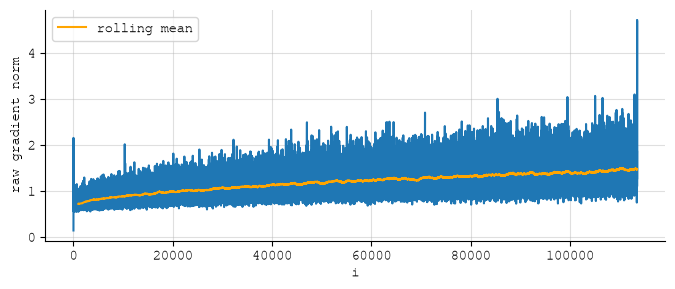

In [36]:
loss_hist_v3_df = pd.DataFrame(loss_hist_v3)
loss_hist_v3_df['grad_norm_val'] = loss_hist_v3_df['grad_norm'].transform(lambda x: x.item())
loss_hist_v3_df['grad_norm_roll'] = loss_hist_v3_df['grad_norm_val'].rolling(window=1000).mean()

plt.figure(figsize=(8, 3))
plt.plot(loss_hist_v3_df['i'], loss_hist_v3_df['grad_norm_val'])
plt.plot(loss_hist_v3_df['i'], loss_hist_v3_df['grad_norm_roll'], color = 'orange', label='rolling mean')
plt.xlabel('i'); plt.ylabel('raw gradient norm')
plt.grid(alpha=0.4)
plt.legend()
sns.despine()

how does the model fair in story generation?

In [26]:
example_query = 'Once upon a time'
tokens = torch.tensor(tokeniser.encode(example_query), dtype=torch.long, device=device).unsqueeze(0)

lm_v3.eval()

response = example_query

with torch.no_grad():
    while True:
        logits = lm_v3(tokens)
        next_token_logits = logits[0, -1, :]

        # 
        probs = torch.softmax(next_token_logits, dim=-1)
        next_token_id = torch.multinomial(probs, num_samples=1).item()

        if next_token_id == tokeniser.eos_token_id: break

        response = response + tokeniser.decode(next_token_id)

        # append new token
        next_token = torch.tensor([[next_token_id]], dtype=torch.long, device=device)
        tokens = torch.cat([tokens, next_token], dim=1)

print(textwrap.fill(response, width=80))

Once upon a time, there was a little girl who loved to play outside. One day,
she saw that his blocks there was a thief. He was scared to run away and even
united. He picked up his package and ran to his mom.  The end the horse wouldn't
say possible skills, and the billboard treasured all right. He then asked his
friend, a little bird, surprise playing better it possible. The squirrel's bad
material.  The frog spent the game yummy they had than the tiny witch.
Everywhere he went, it had a shiny black paw on him. He was so happy. Before
something, it, the bee was just now small ornament and were talking about she
than she was to like her for your a warning.  But the King was it very special.
The shopkeeper had, so anyone was a few colors and bad friends. The boy saw dust
to their orange turkey from a fair lip, but all his friends were happy and
shaking, and then accepted the plant.  The turkey tried. He was toys to not look
so good.   The little girl explored it all the way home. She ne